In [1]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

In [3]:
cells = np.zeros(shape = (80, 45, 4))

In [23]:
def generate_place_field(x, center, width, peak_rate=20.0):
    """Gaussian place field. width = sigma in same units as track.
    x = track location, shape =(track_bins, 1) >>> ndarray"""
    return peak_rate * np.exp(-0.5 * ((x - center) / width) ** 2)

In [52]:
track = np.linspace(0, 450, 45)

centers = np.array([100, 115, 300, 150, 180])
widths  = np.array([25, 30, 10, 20, 12])
peaks   = np.array([5, 6, 2, 22, 20])

fields = np.stack([generate_place_field(track, c, w, p) 
                   for c, w, p in zip(centers, widths, peaks)])

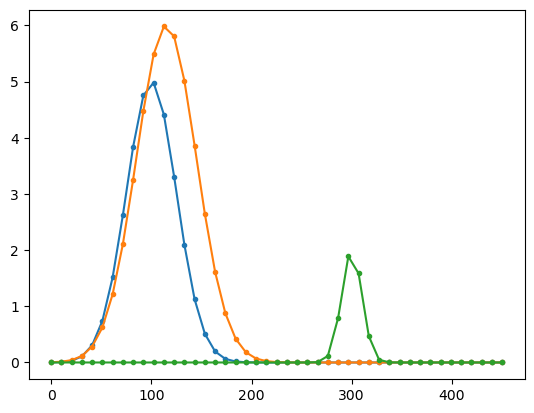

In [53]:
plt.plot(track, fields[0], '.-')
plt.plot(track,fields[1], '.-')
plt.plot(track,fields[2], '.-')

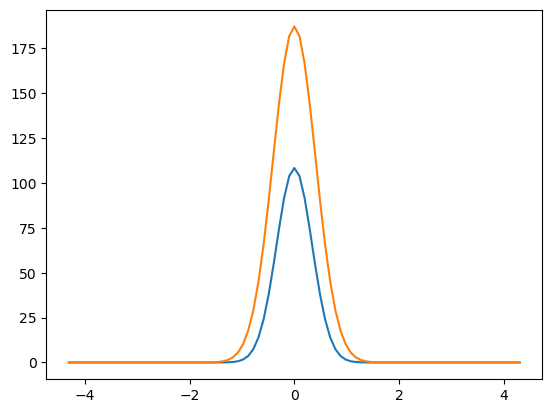

In [56]:
corr1 = np.correlate(fields[0], fields[0], mode = 'full')
corr2 = np.correlate(fields[1], fields[1], mode = 'full')
lags = np.arange(-(len(fields[0]) - 1), len(fields[0])) / (track[1] - track[0])
plt.plot(lags,corr1)
plt.plot(lags,corr2)

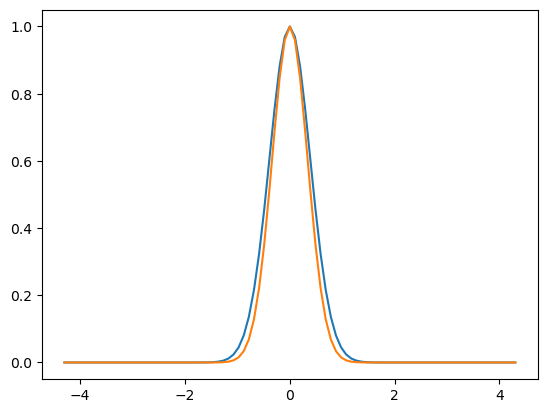

In [57]:
corrcombo = np.correlate(fields[0]+fields[1], fields[0]+fields[1], mode = 'full')

lags = np.arange(-(len(fields[0]) - 1), len(fields[0])) / (track[1] - track[0])
plt.plot(lags,(corrcombo/corrcombo.max()))
plt.plot(lags,(corr1/corr1.max()))


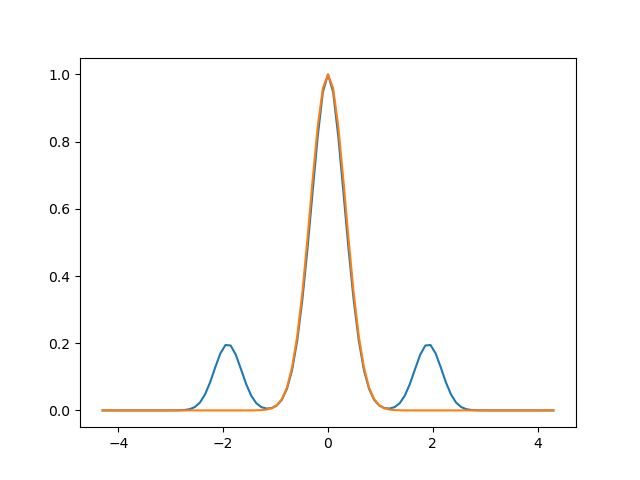

In [64]:
%matplotlib widget
fig = plt.figure()
combo_field = fields[0]+fields[2]
corrcombo = np.correlate(combo_field, combo_field, mode = 'full')

lags = np.arange(-(len(fields[0]) - 1), len(fields[0])) / (track[1] - track[0])
plt.plot(lags,(corrcombo/corrcombo.max()))
plt.plot(lags,(corr1/corr1.max()))


In [193]:
def get_half_width(correlation_density, lags, cutoff_frac = 0.8):
    start = int(len(lags)/2)
  
    for i in range(int(len(lags)/2)):
        explained = np.sum(correlation_density[start - i:start+i:])
        if explained >= cutoff_frac:
            break
    
    return lags[int(len(lags)/2)+i]

def get_half_width_at_pct_of_max(correlation_density, lags, cutoff_frac = 0.5):
    start = int(len(lags)/2)
    cuttoff_cor = correlation_density.max()*cutoff_frac
    for i in range(int(len(lags)/2)):
        val = correlation_density[start+i]

        if val <= cuttoff_cor:
            break
    
    return lags[int(len(lags)/2)+i]

def autocorrelate_field(field, track, max_offset = 100, norm = True, density = True):
    step = track[1]-track[0]
    lags = np.arange(-(len(field) - 1), len(field)) / (1/step)
    if norm:
        field = field/field.max()
    corr = np.correlate(field, field, mode = 'full')
    if max_offset != 0:
        
        max_offset_i = int(np.floor(max_offset/step))
        center = int(len(corr)/2)
        corr = corr[center - max_offset_i:center+max_offset_i]
        lags = lags[center - max_offset_i:center+max_offset_i]

    if density:
        corr = corr/corr.sum()
    
    return corr, lags
    

In [167]:
track = np.linspace(0, 450, 45)

centers = np.array([100, 115, 300, 300, 100])
widths  = np.array([25, 30, 10, 20, 12.5])
peaks   = np.array([5, 6, 1, 1, 5])

fields = np.stack([generate_place_field(track, c, w, p) 
                   for c, w, p in zip(centers, widths, peaks)])

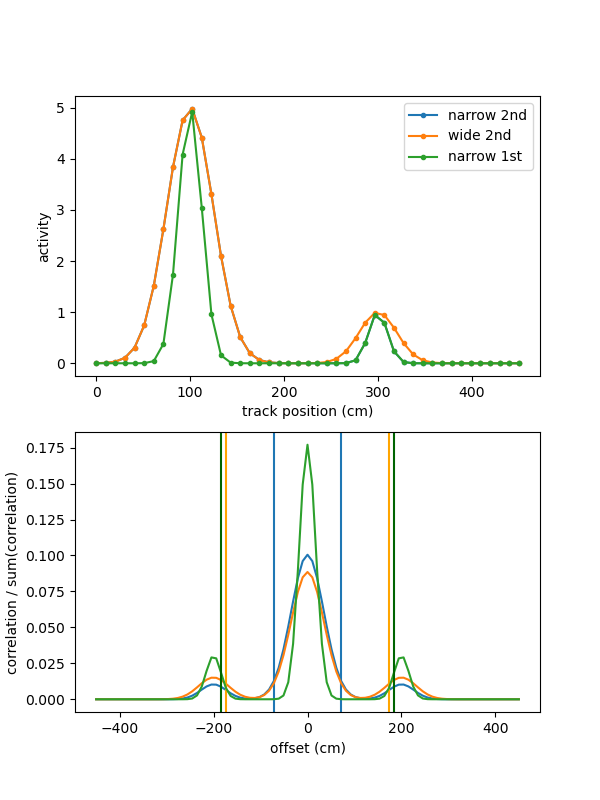

In [168]:
%matplotlib widget
fig, axs = plt.subplots(nrows = 2, figsize = (6,8))
combo_field = fields[0]+fields[2]
corrcombo = np.correlate(combo_field, combo_field, mode = 'full')
corr_density = corrcombo/corrcombo.sum()
axs[0].plot(track, combo_field, '.-', label = 'narrow 2nd')

lags = np.arange(-(len(fields[0]) - 1), len(fields[0])) / (1/(track[1] - track[0]))
axs[1].plot(lags,(corr_density), label = 'narrow 2nd')
hwidth = get_half_width(corr_density, lags)
axs[1].axvline(x = -hwidth)
axs[1].axvline(x = hwidth)



combo_field = fields[0]+fields[3]
corrcombo = np.correlate(combo_field, combo_field, mode = 'full')
corr_density = corrcombo/corrcombo.sum()


axs[0].plot(track, combo_field, '.-', label = 'wide 2nd')
axs[1].plot(lags, corr_density, label = 'wide 2nd')
hwidth = get_half_width(corr_density, lags)
axs[1].axvline(x = -hwidth, color = 'orange')
axs[1].axvline(x = hwidth, color = 'orange')


combo_field = fields[4]+fields[2]
corrcombo = np.correlate(combo_field, combo_field, mode = 'full')
corr_density = corrcombo/corrcombo.sum()
axs[0].plot(track, combo_field, '.-', label = 'narrow 1st')

axs[1].plot(lags,corr_density, label = 'narrow 1st')
hwidth = get_half_width(corr_density, lags)
axs[1].axvline(x = -hwidth, color = 'darkgreen')
axs[1].axvline(x = hwidth, color = 'darkgreen')


axs[0].set_xlabel('track position (cm)')
axs[1].set_xlabel('offset (cm)')

axs[0].set_ylabel('activity')
axs[1].set_ylabel('correlation / sum(correlation)')
axs[0].legend()

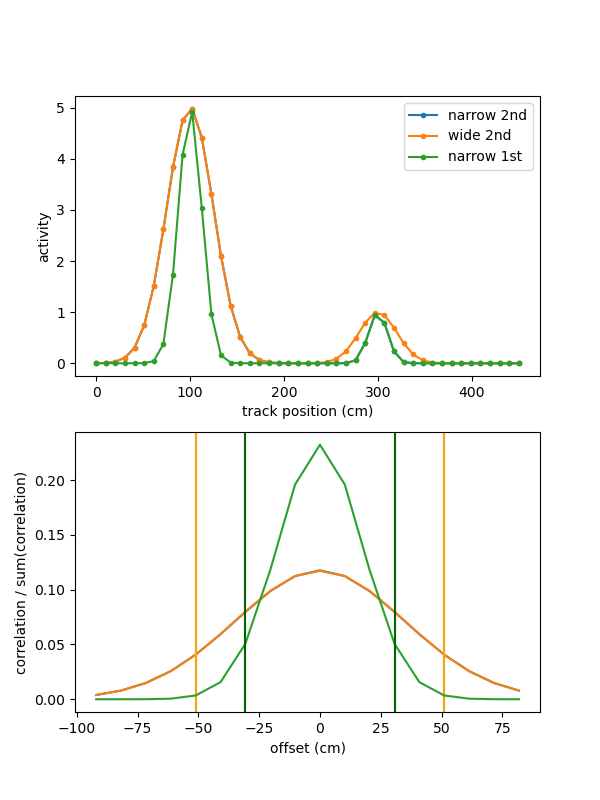

In [169]:

%matplotlib widget
fig, axs = plt.subplots(nrows = 2, figsize = (6,8))
combo_field = fields[0]+fields[2]

corr_density, lags = autocorrelate_field(combo_field, track)

axs[0].plot(track, combo_field, '.-', label = 'narrow 2nd')


axs[1].plot(lags,(corr_density), label = 'narrow 2nd')
hwidth = get_half_width(corr_density, lags)
axs[1].axvline(x = -hwidth)
axs[1].axvline(x = hwidth)



combo_field = fields[0]+fields[3]

corr_density, lags = autocorrelate_field(combo_field, track)


axs[0].plot(track, combo_field, '.-', label = 'wide 2nd')
axs[1].plot(lags, corr_density, label = 'wide 2nd')
hwidth = get_half_width(corr_density, lags)
axs[1].axvline(x = -hwidth, color = 'orange')
axs[1].axvline(x = hwidth, color = 'orange')


combo_field = fields[4]+fields[2]
corr_density, lags = autocorrelate_field(combo_field, track)
axs[0].plot(track, combo_field, '.-', label = 'narrow 1st')

axs[1].plot(lags,corr_density, label = 'narrow 1st')
hwidth = get_half_width(corr_density, lags)
axs[1].axvline(x = -hwidth, color = 'darkgreen')
axs[1].axvline(x = hwidth, color = 'darkgreen')


axs[0].set_xlabel('track position (cm)')
axs[1].set_xlabel('offset (cm)')

axs[0].set_ylabel('activity')
axs[1].set_ylabel('correlation / sum(correlation)')
axs[0].legend()


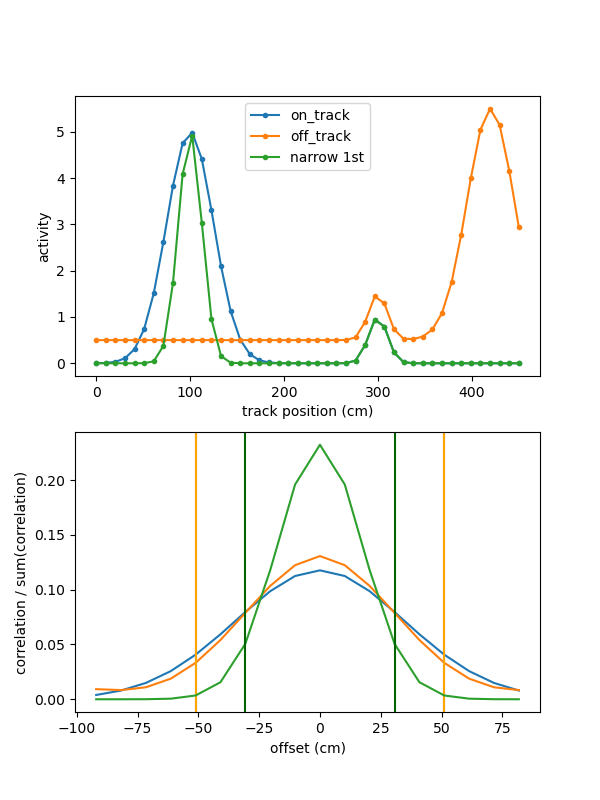

In [170]:
%matplotlib widget

track = np.linspace(0, 450, 45)

centers = np.array([100, 420, 300, 300, 100])
widths  = np.array([25, 25, 10, 20, 12.5])
peaks   = np.array([5, 5, 1, 1, 5])

fields = np.stack([generate_place_field(track, c, w, p) 
                   for c, w, p in zip(centers, widths, peaks)])


fig, axs = plt.subplots(nrows = 2, figsize = (6,8))
combo_field = fields[0]+fields[2]
label = 'on_track'

corr_density, lags = autocorrelate_field(combo_field, track)

axs[0].plot(track, combo_field, '.-', label = label)


axs[1].plot(lags,(corr_density), label = label)
hwidth = get_half_width(corr_density, lags)
axs[1].axvline(x = -hwidth)
axs[1].axvline(x = hwidth)



combo_field = fields[1]+fields[2]
label = 'off_track'

corr_density, lags = autocorrelate_field(combo_field, track)


axs[0].plot(track, combo_field+0.5, '.-', label = label)
axs[1].plot(lags, corr_density, label = label)
hwidth = get_half_width(corr_density, lags)
axs[1].axvline(x = -hwidth, color = 'orange')
axs[1].axvline(x = hwidth, color = 'orange')


combo_field = fields[4]+fields[2]
corr_density, lags = autocorrelate_field(combo_field, track)
axs[0].plot(track, combo_field, '.-', label = 'narrow 1st')

axs[1].plot(lags,corr_density, label = 'narrow 1st')
hwidth = get_half_width(corr_density, lags)
axs[1].axvline(x = -hwidth, color = 'darkgreen')
axs[1].axvline(x = hwidth, color = 'darkgreen')


axs[0].set_xlabel('track position (cm)')
axs[1].set_xlabel('offset (cm)')

axs[0].set_ylabel('activity')
axs[1].set_ylabel('correlation / sum(correlation)')
axs[0].legend()

In [171]:
cell_239 = np.load('protter_tmp_files/cell_gcamp4_d14_239.npy')
cell_114 = np.load('protter_tmp_files/cell_gcamp4_d14_114.npy')

In [172]:
from reward_relative import utilities as ut

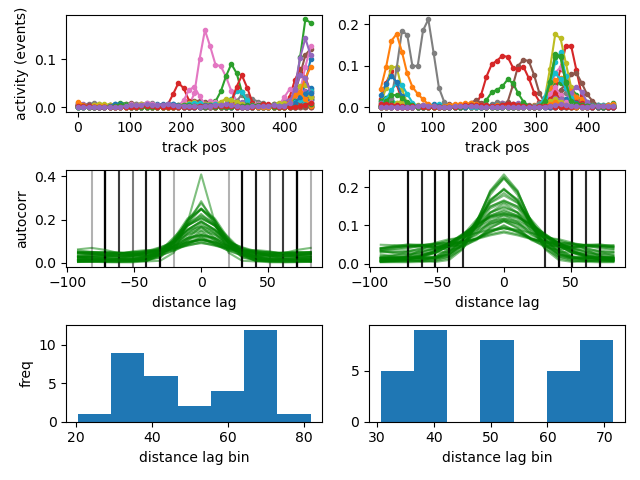

In [173]:
fig, axs = plt.subplots(ncols = 2, nrows = 3)
hw_cell1 = []
hw_cell2 = []
for trial_c1, trial_c2 in zip(cell_239[45:],cell_114[45:]) :
    trial_c1 = ut.nansmooth(trial_c1, sig = 1)
    trial_c2 = ut.nansmooth(trial_c2, sig = 1)
    axs[0,0].plot(track, trial_c1, '.-')
    corr_density, lags = autocorrelate_field(trial_c1, track)
    axs[1,0].plot(lags, corr_density, color = 'green', alpha = 0.5)
    hwidth = get_half_width(corr_density, lags)
    axs[1,0].axvline(x = -hwidth, color = 'black', alpha = 0.3)
    axs[1,0].axvline(x = hwidth, color = 'black', alpha = 0.3)
    hw_cell1+=[[hwidth, trial_c1.max()]]

    axs[0,1].plot(track, trial_c2, '.-')
    corr_density, lags = autocorrelate_field(trial_c2, track)
    axs[1,1].plot(lags, corr_density, color = 'green', alpha = 0.5)

    hwidth = get_half_width(corr_density, lags)
    axs[1,1].axvline(x = -hwidth, color = 'black', alpha = 0.3)
    axs[1,1].axvline(x = hwidth, color = 'black', alpha = 0.3)
    hw_cell2+=[[hwidth, trial_c2.max()]]

hw_cell1 = np.asarray(hw_cell1)
hw_cell2 = np.asarray(hw_cell2)

axs[2,0].hist(hw_cell1[:,0], bins = 'auto')
axs[2,1].hist(hw_cell2[:,0], bins = 'auto')

axs[0,0].set_ylabel('activity (events)')
axs[1,0].set_ylabel('autocorr')
axs[2,0].set_ylabel('freq')

axs[0,0].set_xlabel('track pos')
axs[1,0].set_xlabel('distance lag')
axs[2,0].set_xlabel('distance lag bin')

axs[0,1].set_xlabel('track pos')
axs[1,1].set_xlabel('distance lag')
axs[2,1].set_xlabel('distance lag bin')
fig.tight_layout()

Text(0, 0.5, '80% correlation density half width')

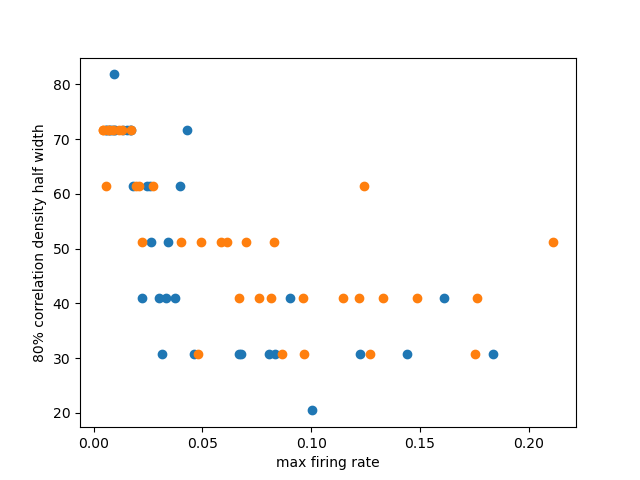

In [174]:
fig, ax = plt.subplots()

ax.scatter(hw_cell1[:,1], hw_cell1[:,0])
ax.scatter(hw_cell2[:,1], hw_cell2[:,0])
ax.set_xlabel('max firing rate')
ax.set_ylabel('80% correlation density half width')

In [175]:
cell_114.shape

(80, 45)

In [176]:
import scipy.stats as sts
z_cell_114 = sts.zscore(cell_114.ravel()).reshape(cell_114.shape)
z_cell_239 = sts.zscore(cell_239.ravel()).reshape(cell_239.shape)

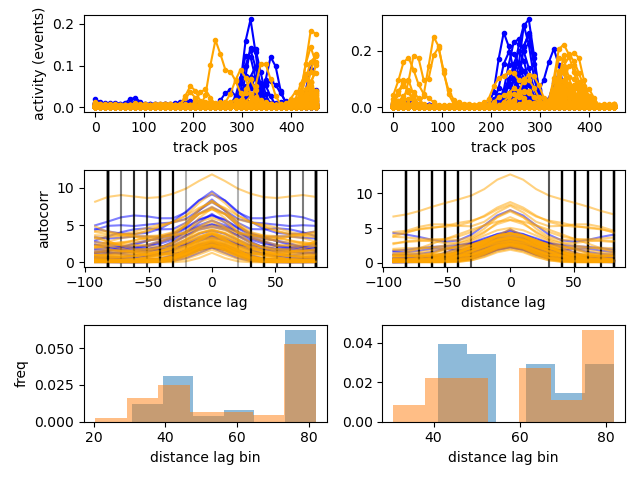

In [177]:
fig, axs = plt.subplots(ncols = 2, nrows = 3)
hw_cell1 = []
hw_cell2 = []
for trial_c1, trial_c2 in zip(cell_239[:30],cell_114[:30]) :
    trial_c1 = ut.nansmooth(trial_c1, sig = 1)
    trial_c2 = ut.nansmooth(trial_c2, sig = 1)
    axs[0,0].plot(track, trial_c1, '.-', color = 'blue')
    corr_density, lags = autocorrelate_field(trial_c1, track, density = False)
    axs[1,0].plot(lags, corr_density, color = 'blue', alpha = 0.5)
    hwidth = get_half_width_at_pct_of_max(corr_density, lags)
    axs[1,0].axvline(x = -hwidth, color = 'black', alpha = 0.3)
    axs[1,0].axvline(x = hwidth, color = 'black', alpha = 0.3)
    hw_cell1+=[[hwidth, trial_c1.max()]]

    axs[0,1].plot(track, trial_c2, '.-',color = 'blue')
    corr_density, lags = autocorrelate_field(trial_c2, track, density = False)
    axs[1,1].plot(lags, corr_density, color = 'blue', alpha = 0.5)

    hwidth = get_half_width_at_pct_of_max(corr_density, lags)
    axs[1,1].axvline(x = -hwidth, color = 'black', alpha = 0.3)
    axs[1,1].axvline(x = hwidth, color = 'black', alpha = 0.3)
    hw_cell2+=[[hwidth, trial_c2.max()]]


hw_2_cell1 = []
hw_2_cell2 = []
for trial_c1, trial_c2 in zip(cell_239[30:],cell_114[30:]) :
    trial_c1 = ut.nansmooth(trial_c1, sig = 1)
    trial_c2 = ut.nansmooth(trial_c2, sig = 1)
    axs[0,0].plot(track, trial_c1, '.-', color = 'orange')
    corr_density, lags = autocorrelate_field(trial_c1, track, density = False)
    axs[1,0].plot(lags, corr_density, color = 'orange', alpha = 0.5)
    hwidth = get_half_width_at_pct_of_max(corr_density, lags)
    axs[1,0].axvline(x = -hwidth, color = 'black', alpha = 0.3)
    axs[1,0].axvline(x = hwidth, color = 'black', alpha = 0.3)
    hw_2_cell1+=[[hwidth, trial_c1.max()]]

    axs[0,1].plot(track, trial_c2, '.-', color = 'orange')
    corr_density, lags = autocorrelate_field(trial_c2, track, density = False)
    axs[1,1].plot(lags, corr_density, color = 'orange', alpha = 0.5)

    hwidth = get_half_width_at_pct_of_max(corr_density, lags)
    axs[1,1].axvline(x = -hwidth, color = 'black', alpha = 0.3)
    axs[1,1].axvline(x = hwidth, color = 'black', alpha = 0.3)
    hw_2_cell2+=[[hwidth, trial_c2.max()]]

hw_cell1 = np.asarray(hw_cell1)
hw_cell2 = np.asarray(hw_cell2)

hw_2_cell1 = np.asarray(hw_2_cell1)
hw_2_cell2 = np.asarray(hw_2_cell2)

axs[2,0].hist(hw_cell1[:,0], bins = 'auto', alpha = 0.5, density = True)
axs[2,1].hist(hw_cell2[:,0], bins = 'auto', alpha = 0.5, density = True)

axs[2,0].hist(hw_2_cell1[:,0], bins = 'auto', alpha = 0.5, density = True)
axs[2,1].hist(hw_2_cell2[:,0], bins = 'auto', alpha = 0.5, density = True)

axs[0,0].set_ylabel('activity (events)')
axs[1,0].set_ylabel('autocorr')
axs[2,0].set_ylabel('freq')

axs[0,0].set_xlabel('track pos')
axs[1,0].set_xlabel('distance lag')
axs[2,0].set_xlabel('distance lag bin')

axs[0,1].set_xlabel('track pos')
axs[1,1].set_xlabel('distance lag')
axs[2,1].set_xlabel('distance lag bin')
fig.tight_layout()

Text(0, 0.5, '80% correlation density half width')

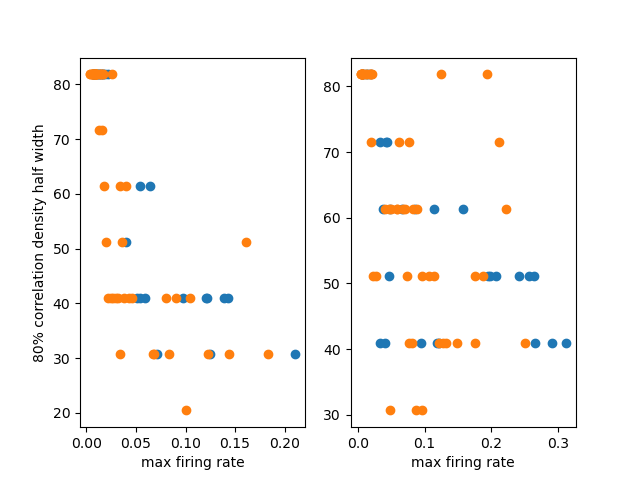

In [178]:
fig, axs = plt.subplots(ncols = 2)

axs[0].scatter(hw_cell1[:,1], hw_cell1[:,0])
axs[0].scatter(hw_2_cell1[:,1], hw_2_cell1[:,0])
axs[1].scatter(hw_cell2[:,1], hw_cell2[:,0])
axs[1].scatter(hw_2_cell2[:,1], hw_2_cell2[:,0])
axs[0].set_xlabel('max firing rate')
axs[1].set_xlabel('max firing rate')
axs[0].set_ylabel('80% correlation density half width')

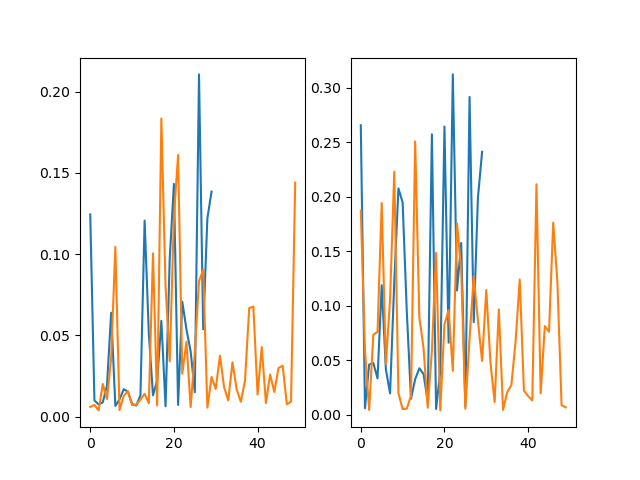

In [181]:
fig, axs = plt.subplots(ncols = 2)
axs[0].plot(hw_cell1[:,1])
axs[0].plot(hw_2_cell1[:,1])

axs[1].plot(hw_cell2[:,1])
axs[1].plot(hw_2_cell2[:,1])

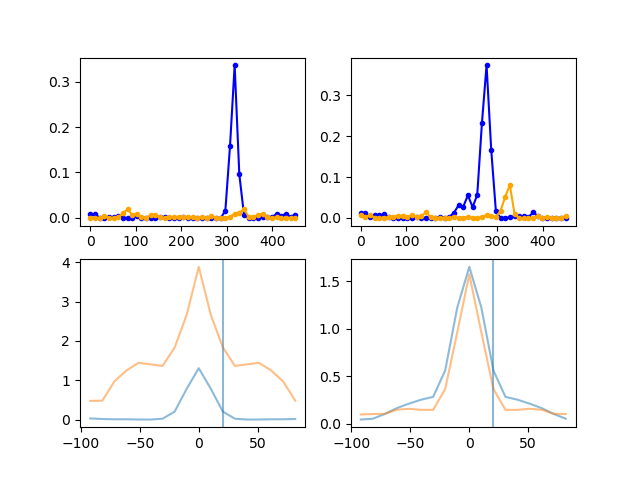

In [195]:
fig, axs = plt.subplots(ncols = 2, nrows=2)
axs_c1 = axs[:,0]
axs_c2 = axs[:,1]

cell_239[26,]
trial_c1 = ut.nansmooth(cell_239[26,:], sig = 0.5)
trial_c2 = ut.nansmooth(cell_239[15,:], sig = 0.5)
axs_c1[0].plot(track, trial_c1, '.-', color = 'blue')
axs_c1[0].plot(track, trial_c2, '.-', color = 'orange')

for trial in [trial_c1, trial_c2]:
    corr_density, lags = autocorrelate_field(trial, track, density = False)
    axs_c1[1].plot(lags, corr_density, alpha = 0.5)
    hwidth = get_half_width_at_pct_of_max(corr_density, lags)
    axs_c1[1].axvline(x = hwidth, alpha = 0.3)





trial_c1 = ut.nansmooth(cell_114[20,:], sig = 0.5)
trial_c2 = ut.nansmooth(cell_239[14,:], sig = 0.5)
axs_c2[0].plot(track, trial_c1, '.-', color = 'blue')
axs_c2[0].plot(track, trial_c2, '.-', color = 'orange')

for trial in [trial_c1, trial_c2]:
    corr_density, lags = autocorrelate_field(trial, track, density = False,)
    axs_c2[1].plot(lags, corr_density, alpha = 0.5)
    hwidth = get_half_width_at_pct_of_max(corr_density, lags)
    axs_c2[1].axvline(x = hwidth, alpha = 0.3)
